# Model B — Distractor & Hint Generator (Traditional ML)
**Course:** Artificial Intelligence — BS(CS) Spring 2026

## What Model B Must Do (PRD)
1. **Distractors**: Given passage, question, and correct answer letter/text, propose **three** wrong-but-plausible MC options (from passage cues + similarity).
2. **Hints**: **Extractive**, ranked clues from the passage (graduated: weaker → stronger cues).

## Prerequisites
Run **`EDA.ipynb`** then **`preprocessing.ipynb`** first.

This notebook uses:
- `data/processed/train_split.csv`, `val_split.csv`
- `models/model_b/traditional/tfidf_vectorizer.pkl`, `cos_vectorizer.pkl` (frozen; **never refit on val/test**)

## Approach
- **Distractor ranker**: Sentence/snippet candidates from the passage → features (TF-IDF cosine to gold & question & article prefix; `cos_vectorizer` parallels; lexical overlap).
  - **Train**: Official RACE **wrong options** vs **hard negatives** (gold answer text + unrelated sentences).
  - Models: **Logistic Regression**, **Random Forest**.
- **Hint scorer**: **Logistic Regression** on sentence features using **silver labels** (sentences ranking high vs low by cosine-to-question+gold heuristic).

Outputs: `models/model_b/traditional/distractor_ranker.pkl`, `hint_scorer.pkl`, `random_forest_distractor.pkl`, `model_b_config.pkl`.


## Cell 1 — Imports & paths

In [5]:
import os
import re
import warnings
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings('ignore')
np.random.seed(42)

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
PROC = ROOT / 'data' / 'processed'
MODELB = ROOT / 'models' / 'model_b' / 'traditional'
RESULTS = ROOT / 'results' / 'model_b'
RESULTS.mkdir(parents=True, exist_ok=True)

print('ROOT =', ROOT)

ROOT = /home/talha-shafi/FAST/AI/proj/race_rc_project


## Cell 2 — Cleaning helpers (aligned with preprocessing)

In [6]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\b\d+\b', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()


def truncate_article(text, max_words=500):
    words = text.split()
    return ' '.join(words[:max_words]) if len(words) > max_words else text


def clean_dataframe(df):
    df = df.copy()
    for col in ['article', 'question', 'A', 'B', 'C', 'D']:
        df[f'{col}_clean'] = df[col].apply(clean_text)
    df['article_clean'] = df['article_clean'].apply(truncate_article)
    return df


def split_sentences(article_clean, min_tokens=8, chunk_words=40, overlap=15):
    """Split passage into ≥2 snippets for hints / distractor mining.
    `clean_text` removes .?! so regex split usually fails — use word windows."""
    tokens = article_clean.split()
    if len(tokens) < min_tokens:
        return ([article_clean] if article_clean.strip() else [])

    parts = re.split(r'(?<=[.!?])\s+', article_clean)
    out = []
    for p in parts:
        p = p.strip()
        if len(p.split()) >= min_tokens:
            out.append(p)

    if len(out) < 2:
        out.clear()
        step = max(1, chunk_words - overlap)
        i = 0
        while i < len(tokens):
            chunk = tokens[i:i + chunk_words]
            if len(chunk) >= min_tokens:
                out.append(' '.join(chunk))
            i += step
        if len(out) < 2 and len(tokens) >= min_tokens * 2:
            mid = max(min_tokens, len(tokens) // 2)
            out = [' '.join(tokens[:mid]), ' '.join(tokens[mid:])]

    if not out and tokens:
        out = [' '.join(tokens[:max(min_tokens, min(len(tokens), 30))])]
    return out


def norm_key(s):
    return re.sub(r'\s+', ' ', str(s).lower().strip())


def jaccard_tokens(a, b):
    ta, tb = set(a.split()), set(b.split())
    if not ta or not tb:
        return 0.0
    return len(ta & tb) / len(ta | tb)


train_df_raw = pd.read_csv(PROC / 'train_split.csv')
val_df_raw = pd.read_csv(PROC / 'val_split.csv')
train_df = clean_dataframe(train_df_raw)
val_df = clean_dataframe(val_df_raw)
print('train', train_df.shape, 'val', val_df.shape)

train (70281, 21) val (17571, 21)


## Cell 3 — Load vectorizers

In [7]:
tfidf_vec = joblib.load(MODELB / 'tfidf_vectorizer.pkl')
cos_vec = joblib.load(MODELB / 'cos_vectorizer.pkl')
print('Loaded:', MODELB / 'tfidf_vectorizer.pkl')

Loaded: /home/talha-shafi/FAST/AI/proj/race_rc_project/models/model_b/traditional/tfidf_vectorizer.pkl



## Cell 4 — Engineer distractor training data

Tune **`MAX_TRAIN_ROWS`** down if RAM is tight. Default uses up to ~40k training questions.


In [8]:
MAX_TRAIN_ROWS = min(40000, len(train_df))
ARTICLE_PREFIX_WORDS = 120


def article_prefix(aclean):
    return ' '.join(aclean.split()[:ARTICLE_PREFIX_WORDS])


def row_option_clean(row, letter):
    return row[f'{letter}_clean']


def cand_features_row(cand, gold, question, article_prefix_txt):
    """8-dim dense feature vector for one candidate snippet."""
    m = tfidf_vec.transform([cand, gold, question, article_prefix_txt])
    c, g, q, ap = m[0], m[1], m[2], m[3]
    cos_cg = float(cosine_similarity(c, g)[0, 0])
    cos_cq = float(cosine_similarity(c, q)[0, 0])
    cos_cap = float(cosine_similarity(c, ap)[0, 0])
    cav = cos_vec.transform([cand])
    mav = cos_vec.transform([question + ' ' + gold])
    car = cos_vec.transform([article_prefix_txt])
    cos_c_art = float(cosine_similarity(cav, car)[0, 0])
    cos_c_qgold = float(cosine_similarity(cav, mav)[0, 0])
    return np.array([
        cos_cg, cos_cq, cos_cap, cos_c_art, cos_c_qgold,
        np.log1p(len(cand.split())), jaccard_tokens(cand, question), jaccard_tokens(cand, gold)
    ], dtype=np.float32)


def build_distractor_xy(sample_df, rng, negatives_per_positive=2):
    X, y = [], []
    for i in range(len(sample_df)):
        row = sample_df.iloc[i]
        gold_letter = row['answer']
        gold = row_option_clean(row, gold_letter)
        q = row['question_clean']
        art = row['article_clean']
        ap = article_prefix(art)

        wrong_letters = [L for L in 'ABCD' if L != gold_letter]
        positives = [norm_key(row_option_clean(row, L)) for L in wrong_letters]
        positives = [p for p in positives if len(p) >= 3]

        for pos in positives:
            X.append(cand_features_row(pos, gold, q, ap))
            y.append(1)

        sents = split_sentences(art)
        neg_pool = [('gold', gold)]
        rng.shuffle(sents)
        for s in sents:
            sk = norm_key(s)
            if sk == gold or sk in positives or len(sk) < 10:
                continue
            if any(jaccard_tokens(sk, p) > 0.88 for p in positives):
                continue
            neg_pool.append(('sent', sk))

        need = max(1, len(positives) * negatives_per_positive)
        rng.shuffle(neg_pool)
        picked = 0
        for _src, cand in neg_pool:
            if picked >= need:
                break
            X.append(cand_features_row(cand, gold, q, ap))
            y.append(0)
            picked += 1

    return np.stack(X), np.array(y, dtype=np.int64)


rng = np.random.RandomState(42)
sub_train = train_df.iloc[:MAX_TRAIN_ROWS].copy()
print('Building distractor XY on', len(sub_train), 'rows...')
X_distr, y_distr = build_distractor_xy(sub_train, rng)
print('X_distr:', X_distr.shape, 'pos rate:', y_distr.mean().round(3))

Building distractor XY on 40000 rows...
X_distr: (351400, 8) pos rate: 0.335


## Cell 5 — Train distractor rankers

=== Logistic Regression (hold-out slice on train-constructed data) ===
[LR ] acc=0.9506  F1=0.9278  Prec=0.8949  Rec=0.9633
              precision    recall  f1-score   support

    negative       0.98      0.94      0.96      6704
  distractor       0.89      0.96      0.93      3296

    accuracy                           0.95     10000
   macro avg       0.94      0.95      0.95     10000
weighted avg       0.95      0.95      0.95     10000

=== RandomForest ===
[RF ] acc=0.9819  F1=0.9729  Prec=0.9601  Rec=0.9860
              precision    recall  f1-score   support

    negative       0.99      0.98      0.99      6704
  distractor       0.96      0.99      0.97      3296

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



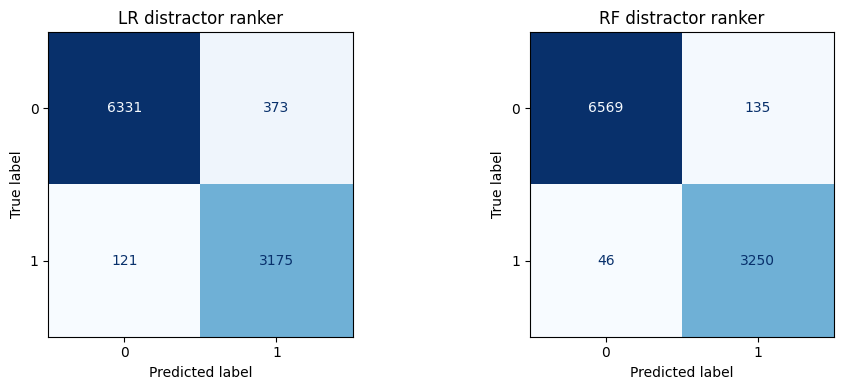

In [9]:
lr_dist = LogisticRegression(max_iter=2000, C=1.0, solver='lbfgs', class_weight='balanced')
lr_dist.fit(X_distr, y_distr)

rf_dist = RandomForestClassifier(
    n_estimators=200, max_depth=12, random_state=42, n_jobs=-1, class_weight='balanced_subsample'
)
rf_dist.fit(X_distr, y_distr)


def report_split(name, model, X, y):
    pred = model.predict(X)
    print(f'[{name}] acc={accuracy_score(y, pred):.4f}  F1={(f1_score(y, pred)):.4f}  Prec={precision_score(y,pred):.4f}  Rec={recall_score(y,pred):.4f}')
    print(classification_report(y, pred, target_names=['negative', 'distractor']))

n = min(len(X_distr), 50000)
idx = rng.permutation(len(X_distr))[:n]
Xt, yt = X_distr[idx], y_distr[idx]
split = int(0.8 * len(Xt))
Xtr, Xva = Xt[:split], Xt[split:]
ytr, yva = yt[:split], yt[split:]

lr_dist.fit(Xtr, ytr)
rf_dist.fit(Xtr, ytr)
print('=== Logistic Regression (hold-out slice on train-constructed data) ===')
report_split('LR ', lr_dist, Xva, yva)
print('=== RandomForest ===')
report_split('RF ', rf_dist, Xva, yva)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay(confusion_matrix(yva, lr_dist.predict(Xva))).plot(ax=ax[0], cmap='Blues', colorbar=False)
ax[0].set_title('LR distractor ranker')
ConfusionMatrixDisplay(confusion_matrix(yva, rf_dist.predict(Xva))).plot(ax=ax[1], cmap='Blues', colorbar=False)
ax[1].set_title('RF distractor ranker')
plt.tight_layout()
plt.savefig(RESULTS / 'distractor_confusion_holdout.png', dpi=150)
plt.show()

## Cell 6 — `generate_distractors` — greedy top-3 with diversity penalty

Inference uses LR **probability of class distractor**.

In [10]:
def generate_distractors(article_clean, question_clean, gold_answer_clean, rng, model, min_sent_tokens=10, beam=48):
    """Return up to three option strings mined from sentences (excluding near-gold)."""
    sentences = split_sentences(article_clean, min_tokens=min_sent_tokens)
    ap = article_prefix(article_clean)
    gold = norm_key(gold_answer_clean)

    scored = []
    for s in sentences:
        cand = norm_key(s)
        if len(cand) < 12:
            continue
        if jaccard_tokens(cand, gold) > 0.92:
            continue
        feats = cand_features_row(cand, gold, question_clean, ap).reshape(1, -1)
        prob = float(model.predict_proba(feats)[0, 1])
        scored.append((prob, cand))

    scored.sort(key=lambda x: x[0], reverse=True)
    chosen = []
    for prob, cand in scored:
        if len(chosen) >= 3:
            break
        if all(jaccard_tokens(cand, ch) < 0.55 for ch in chosen):
            chosen.append(cand)
        if len(scored) < beam and len(chosen) >= 3:
            break

    # pad from medium-similarity sentences if needed
    if len(chosen) < 3:
        for prob, cand in scored[len(chosen):]:
            if cand in chosen:
                continue
            if jaccard_tokens(cand, gold) > 0.85:
                continue
            chosen.append(cand)
            if len(chosen) >= 3:
                break
    return chosen[:3]


rng_val = np.random.RandomState(0)
scores_hit = []

for idx in range(min(500, len(val_df))):  # quick val sample
    row = val_df.iloc[idx]
    gl = row['answer']
    gold_c = row_option_clean(row, gl)
    q = row['question_clean']
    art = row['article_clean']

    gens = generate_distractors(art, q, gold_c, rng_val, lr_dist)
    refs = set(norm_key(row_option_clean(row, L)) for L in 'ABCD' if L != gl)

    best_j = 0.0
    for g in gens:
        for r in refs:
            best_j = max(best_j, jaccard_tokens(g, r))
    scores_hit.append(best_j)

print(
    'Val sample (first 500 ex.): mean max Jaccard(generated vs any gold distractor) = ',
    round(float(np.mean(scores_hit)), 4),
)

joblib.dump(lr_dist, MODELB / 'distractor_ranker.pkl')
joblib.dump(rf_dist, MODELB / 'random_forest_distractor.pkl')
print('Saved:', MODELB / 'distractor_ranker.pkl')

Val sample (first 500 ex.): mean max Jaccard(generated vs any gold distractor) =  0.0976
Saved: /home/talha-shafi/FAST/AI/proj/race_rc_project/models/model_b/traditional/distractor_ranker.pkl


## Cell 7 — Hint silver labels + train hint scorer

In [11]:
def sentence_silver_score(sent, question, gold, article_prefix_txt):
    m = tfidf_vec.transform([sent, question, gold, article_prefix_txt])
    s, q, g, ap = m[0], m[1], m[2], m[3]
    return (
        float(cosine_similarity(s, q)[0, 0])
        + 0.8 * float(cosine_similarity(s, g)[0, 0])
        + 0.2 * float(cosine_similarity(s, ap)[0, 0])
    )


def build_hint_xy(sample_df, rng, top_frac=0.25):
    Xh, yh = [], []
    for i in range(len(sample_df)):
        row = sample_df.iloc[i]
        gl = row['answer']
        gold = row_option_clean(row, gl)
        q = row['question_clean']
        art = row['article_clean']
        ap = article_prefix(art)
        sents = split_sentences(art, min_tokens=6)
        if len(sents) < 2:
            continue
        scr = [sentence_silver_score(s, q, gold, ap) for s in sents]
        thr = np.quantile(scr, 1.0 - top_frac)
        for j, (s, sc) in enumerate(zip(sents, scr)):
            pos = int(sc >= thr)
            slen = len(s.split())
            cav = cos_vec.transform([s])
            qv = cos_vec.transform([q])
            gv = cos_vec.transform([gold])
            Xh.append(np.array([
                slen,
                np.log1p(slen),
                jaccard_tokens(s, q),
                jaccard_tokens(s, gold),
                float(cosine_similarity(cav, qv)[0, 0]),
                float(cosine_similarity(cav, gv)[0, 0]),
                float(cosine_similarity(cav, cos_vec.transform([ap]))[0, 0]),
                j / max(1, len(sents) - 1),
            ], dtype=np.float32))
            yh.append(pos)
    if not Xh:
        raise ValueError("No hint training rows built — lower min_tokens or check article_clean")
    return np.stack(Xh), np.array(yh, dtype=np.int64)


sub_h = train_df.iloc[: min(30000, len(train_df))].copy()
Xh, yh = build_hint_xy(sub_h, rng)
print('Hint training:', Xh.shape, 'positive rate', yh.mean().round(3))

lr_hint = LogisticRegression(max_iter=1500, class_weight='balanced')
lr_hint.fit(Xh, yh)
pred = lr_hint.predict(Xh)
print('Train acc', accuracy_score(yh, pred), 'F1', f1_score(yh, pred))

joblib.dump(lr_hint, MODELB / 'hint_scorer.pkl')
print('Saved', MODELB / 'hint_scorer.pkl')

Hint training: (339718, 8) positive rate 0.282
Train acc 0.7740773229560989 F1 0.6502811420655967
Saved /home/talha-shafi/FAST/AI/proj/race_rc_project/models/model_b/traditional/hint_scorer.pkl


## Cell 8 — Rank hints for validation sample

In [12]:
def rank_hints(article_clean, question_clean, gold_answer_clean, model, top_k=3):
    ap = article_prefix(article_clean)
    gold = norm_key(gold_answer_clean)
    sents = split_sentences(article_clean, min_tokens=6)
    feats = []
    for j, s in enumerate(sents):
        slen = len(s.split())
        cav = cos_vec.transform([s])
        qv = cos_vec.transform([question_clean])
        gv = cos_vec.transform([gold])
        feats.append(np.array([
            slen,
            np.log1p(slen),
            jaccard_tokens(s, question_clean),
            jaccard_tokens(s, gold),
            float(cosine_similarity(cav, qv)[0, 0]),
            float(cosine_similarity(cav, gv)[0, 0]),
            float(cosine_similarity(cav, cos_vec.transform([ap]))[0, 0]),
            j / max(1, len(sents) - 1),
        ], dtype=np.float32))
    if not feats:
        return []
    F = np.stack(feats)
    prob = model.predict_proba(F)[:, 1]
    order = np.argsort(-prob)
    return [sents[i] for i in order[:top_k]]


overlap_rates = []
for idx in range(min(300, len(val_df))):
    row = val_df.iloc[idx]
    gl = row['answer']
    gold_c = row_option_clean(row, gl)
    q = row['question_clean']
    art = row['article_clean']
    hints = rank_hints(art, q, gold_c, lr_hint, top_k=3)
    gold_words = set(gold_c.split())
    best = 0.0
    for h in hints:
        best = max(best, len(gold_words & set(h.split())) / max(1, len(gold_words)))
    overlap_rates.append(best)

print('Val hint sample: mean word-overlap of top-3 hint sentences with gold answer:', round(float(np.mean(overlap_rates)), 4))

Val hint sample: mean word-overlap of top-3 hint sentences with gold answer: 0.5646


## Cell 9 — Save config bundle for Streamlit / inference

In [13]:
cfg = {
    'feature_dim_distractor': 8,
    'article_prefix_words': ARTICLE_PREFIX_WORDS,
    'train_rows_distractor': int(MAX_TRAIN_ROWS),
    'models': ['distractor_ranker.pkl', 'hint_scorer.pkl', 'random_forest_distractor.pkl'],
}
joblib.dump(cfg, MODELB / 'model_b_config.pkl')
print('Done. Artifacts in', MODELB)

Done. Artifacts in /home/talha-shafi/FAST/AI/proj/race_rc_project/models/model_b/traditional


In [19]:
import joblib
from pathlib import Path

config = joblib.load(Path.cwd().parent / 'models' / 'model_b' / 'traditional' / 'model_b_config.pkl')
print(config.keys())

for k, v in config.items():
    print(k, ':', type(v), ':', repr(v) if not hasattr(v, 'predict') else '<model>')
print(config['feature_dim_distractor'])
print(config['article_prefix_words'])
print(config['train_rows_distractor'])



dict_keys(['feature_dim_distractor', 'article_prefix_words', 'train_rows_distractor', 'models'])
feature_dim_distractor : <class 'int'> : 8
article_prefix_words : <class 'int'> : 120
train_rows_distractor : <class 'int'> : 40000
models : <class 'list'> : ['distractor_ranker.pkl', 'hint_scorer.pkl', 'random_forest_distractor.pkl']
8
120
40000
